In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set(style='whitegrid')

# Load Dataset

In [41]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# Task 1: Identify Data Quality Issues

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

--- Missing Values Count ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

--- Descriptive Statistics ---


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


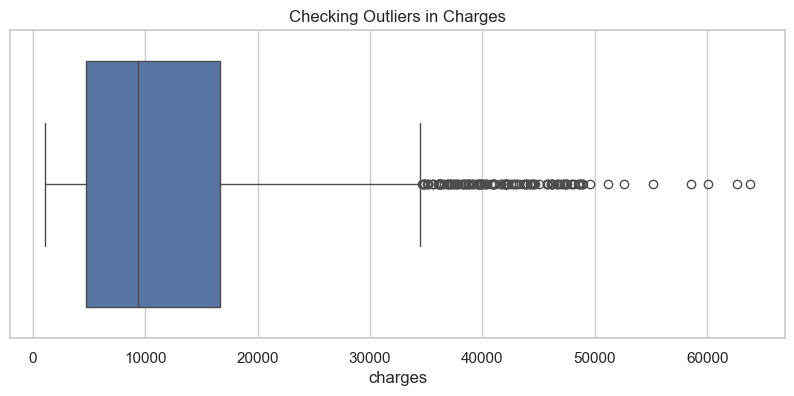

In [42]:
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

print("\n--- Descriptive Statistics ---")
display(df.describe())

# Visualization to check for outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['charges'])
plt.title('Checking Outliers in Charges')
plt.show()

Findings:

Data Consistency: The dataset consists of 1,338 rows and 7 columns.
Categorical variables (sex, smoker, region) are correctly identified as objects, and numerical variables (age, bmi, children, charges) are correctly identified as float/int.

Missing Values: After running df.isnull().sum(), it is confirmed that there are no missing values in the dataset.

Outliers Detection: Initial statistical analysis and boxplots show significant outliers in the charges column and some potential outliers in the bmi column.

## Introduce Artificial Missing Values

In [43]:
# Create a copy of the dataframe
df2 = df.copy()

# Introduce artificial missing values in the 'bmi' column (first 6 rows)
df2.loc[0:5, 'bmi'] = np.nan

print(df2.isnull().sum())

age         0
sex         0
bmi         6
children    0
smoker      0
region      0
charges     0
dtype: int64


In [44]:
df2.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,NaN,0,yes,southwest,16884.92400
1,18,male,NaN,1,no,southeast,1725.55230
2,28,male,NaN,3,no,southeast,4449.46200
3,33,male,NaN,0,no,northwest,21984.47061
4,32,male,NaN,0,no,northwest,3866.85520


# Task 2: Apply one missing value strategy

In [45]:
# Strategy: Median Imputation
# Reason: Median is robust to outliers, which we detected in Task 1.
df_median = df2.copy()
df_median['bmi'] = df_median['bmi'].fillna(df_median['bmi'].median())

In [46]:
df_median.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,30.4,0,yes,southwest,16884.92400
1,18,male,30.4,1,no,southeast,1725.55230
2,28,male,30.4,3,no,southeast,4449.46200
3,33,male,30.4,0,no,northwest,21984.47061
4,32,male,30.4,0,no,northwest,3866.85520


Since the original dataset had no missing values, artificial missing values were introduced to the bmi column for demonstration purposes.

Strategy Applied: Median Imputation.

Why? - We used df2.loc[0:5, 'bmi'] = np.nan to simulate missing data.

We then applied the Median to fill these gaps.

Justification: The median was chosen because it is more robust and less affected by outliers compared to the mean, ensuring our data remains representative.

# Task 3: Detect and handle outliers using IQR 

In [47]:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile) for charges
Q1 = df_median['charges'].quantile(0.25)
Q3 = df_median['charges'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the outlier bounds
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# 3. Identify outliers
outliers_charges = df_median[(df_median['charges'] < lower) | (df_median['charges'] > upper)]
print(f"Number of outliers detected in Charges: {len(outliers_charges)}")

Number of outliers detected in Charges: 139


### Remove Outliers

In [48]:
# 4. Handle outliers by filtering them out
df3 = df_median[(df_median['charges'] >= lower) & (df2['charges'] <= upper)].copy()

print(f"Dataset size before: {len(df2)}")
print(f"Dataset size after removing outliers: {len(df3)}")

Dataset size before: 1338
Dataset size after removing outliers: 1199


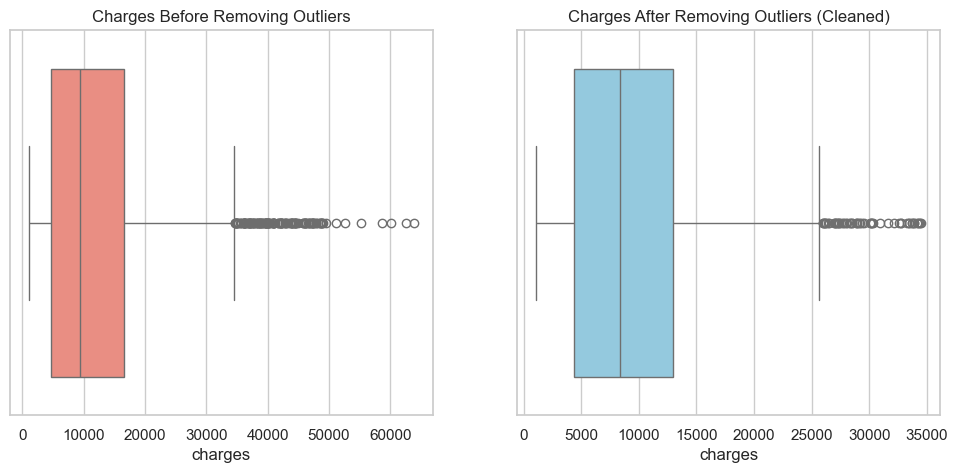

In [49]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x=df2['charges'], color='salmon')
plt.title('Charges Before Removing Outliers')

plt.subplot(1, 2, 2)
sns.boxplot(x=df3['charges'], color='skyblue')
plt.title('Charges After Removing Outliers (Cleaned)')

plt.show()

In [50]:
print(df3.isnull().sum())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In this task, I used the Interquartile Range (IQR) method to identify and handle outliers in the charges column.

Steps Taken:

Identification: Calculated $Q1$ (25th percentile) and $Q3$ (75th percentile) to determine the $IQR$.

Boundary Setting: Established the upper and lower whiskers using the formula:

$Upper Bound = Q3 + (1.5 \times IQR)$.

Action (Removal): A total of 139 outliers were detected and removed from the dataset to ensure a more normal distribution for the predictive model.

Analysis of Result:

Before Removal: The boxplot shows a significant number of extreme values (outliers) reaching up to 60,000, which can skew statistical measures like the mean.

After Removal: The cleaned dataset (df3) shows a much more stable and compact distribution of medical charges, limited to a maximum of approximately 35,000.

# Task 4: Normalize numerical features using both Min-Max and Z-score.

### Min-Max Normalization

In [51]:
from sklearn.preprocessing import MinMaxScaler

# 1. Initialize the MinMaxScaler
min_max_scaler = MinMaxScaler()

# 2. Create a copy of the dataframe for normalization
df_normalized = df3.copy()

# 3. Apply normalization to numerical columns
num_cols = ['age', 'bmi', 'children', 'charges']
df_normalized[num_cols] = min_max_scaler.fit_transform(df3[num_cols])

# 4. Show the first 5 rows to see the transformation
print("Data after Min-Max Normalization (Scale 0-1):")
df_normalized[num_cols].head()

Data after Min-Max Normalization (Scale 0-1):


,age,bmi,children,charges
0,0.021739,0.388485,0.0,0.472641
1,0.000000,0.388485,0.2,0.018101
2,0.217391,0.388485,0.6,0.099775
3,0.326087,0.388485,0.0,0.625547
4,0.304348,0.388485,0.0,0.082306


### Z-Score Normalization

In [52]:
from sklearn.preprocessing import StandardScaler

# 1. Initialize the StandardScaler
std_scaler = StandardScaler()

# 2. Create a copy of the dataframe for standardization
df_standardized = df3.copy()

# 3. Apply Z-score standardization to numerical columns
num_cols = ['age', 'bmi', 'children', 'charges']
df_standardized[num_cols] = std_scaler.fit_transform(df3[num_cols])

# 4. Show the first 5 rows to see the transformation
print("Data after Z-score Standardization (Mean=0, Std=1):")
df_standardized[num_cols].head()

Data after Z-score Standardization (Mean=0, Std=1):


,age,bmi,children,charges
0,-1.421544,0.049345,-0.893260,0.961182
1,-1.492656,0.049345,-0.069399,-1.133192
2,-0.781529,0.049345,1.578322,-0.756865
3,-0.425965,0.049345,-0.893260,1.665721
4,-0.497078,0.049345,-0.893260,-0.837356


In this task, I applied two different scaling techniques to ensure all numerical features are on a comparable scale:

Min-Max Normalization: Scales data to a fixed range between 0 and 1. 
This is useful for algorithms that do not assume any specific distribution.

Z-score Standardization: Scales data so that it has a mean of 0 and a standard deviation of 1. 
This is better for models that assume the data follows a Gaussian (normal) distribution.

# Task 5: Check Correlation before PCA

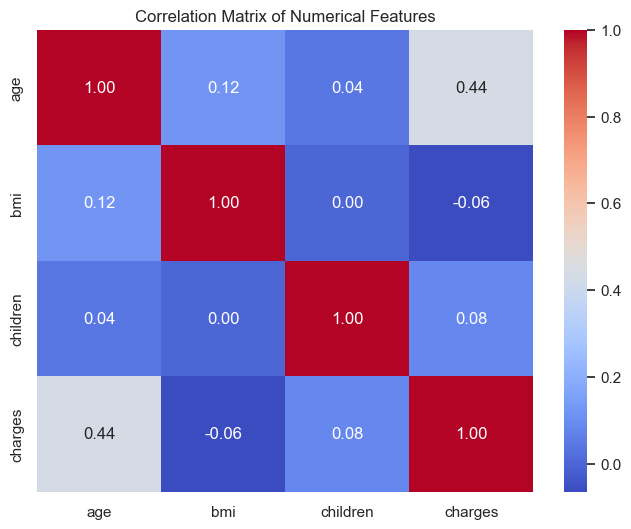

In [53]:
corr_matrix = df3[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

The heatmap shows the correlation between the numerical features


There is a moderate positive correlation of 0.44 between age and charges.
This indicates that as age increases, insurance charges also tend to increase. Since there is a clear relationship between these variables, applying PCA is justified to reduce the dimensionality of the data while capturing the most significant variance.

## Applying PCA

In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(df_standardized[['age', 'bmi', 'children', 'charges']])

df_pca = pd.DataFrame(data=pca_data, columns=['Principal Component 1', 'Principal Component 2'])

df_pca.head()

,Principal Component 1,Principal Component 2
0,-0.491299,-0.146835
1,-1.827479,0.046240
2,-0.765407,-0.378822
3,0.686452,-0.123493
4,-1.084941,0.389529


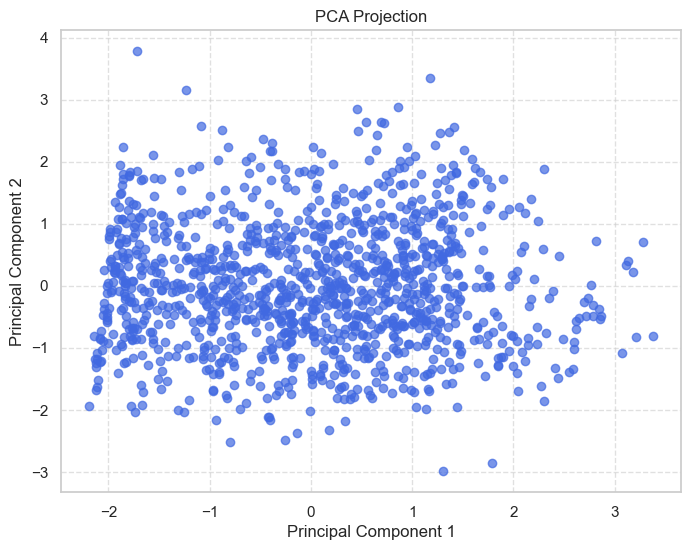

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(df_pca['Principal Component 1'], df_pca['Principal Component 2'], color='royalblue', alpha=0.7)

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True, linestyle='--', alpha=0.6)

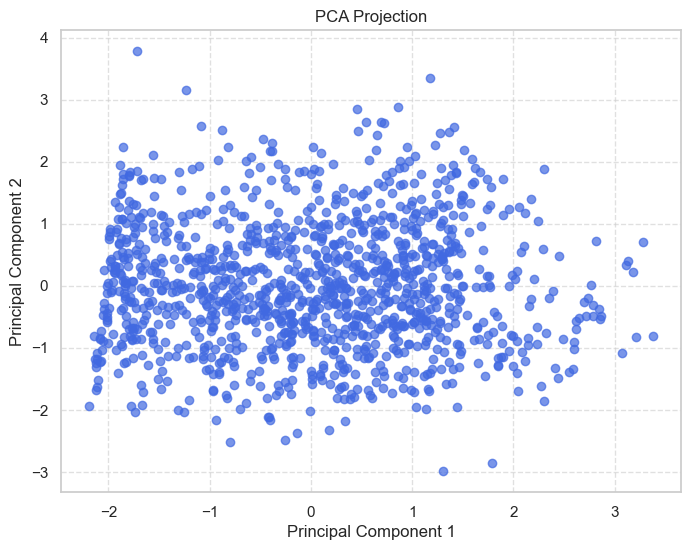

In [ ]:
plt.show()

The 4 original numerical features have been successfully transformed into 2 principal components (PC1 and PC2).
This reduction simplifies the dataset for future modeling and removes redundancy caused by the correlation we found earlier.

The new components represent a combination of the original data, where PC1 captures the maximum possible variance in the dataset.